# Guided Numeric Exploration — Breast Cancer DNA Methylation
_Sample-level and probe-subsample walkthrough of tumor vs normal methylation profiles_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [lyndialu/breast-cancer-dna-methylation-dataset](https://www.kaggle.com/datasets/lyndialu/breast-cancer-dna-methylation-dataset)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.
Indented lines signify code is part of a larger function or loop. Functions are used to keep the exploratory process simple and reusable.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Layout](#Setup)** <br>
**3. [Sample-Level Summaries](#Sample)** <br>
**4. [Tumor vs Normal — Univariate](#Univariate)** <br>
**5. [Missingness and Extreme Methylation](#Missing)** <br>
**6. [Probe Subsample Matrix](#Matrix)** <br>
**7. [PCA and Class Separation](#PCA)** <br>
**8. [Differential Probes (Exploratory)](#Diff)** <br>
**9. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This notebook is a guided observational walkthrough of a **Illumina 450K-style** DNA methylation archive: **371 normal** and **844 tumor** breast-tissue samples. Each sample is a text file with **453,001** lines — one numeric value per CpG probe, in a fixed probe order shared across files. Values in \([0,1]\) are β-values (fraction methylated); **`-1` marks missing / failed probes**.

My goal is not to train a clinical classifier from scratch in one pass. It is to understand the **shape of the data**: how tumor and normal samples differ in average methylation, missingness, hyper-/hypomethylation mass, and whether a *modest* random probe subsample already separates classes in PCA space. Full 450K × 1,215 matrices are large; I therefore work in two layers — **cheap sample summaries over all files**, then a **deliberately smaller probe×sample matrix** for multivariate views.

Interpretations are associational epigenomic patterns, not diagnostic claims.


# **2. Setup and Data Layout:** <a id="Setup"></a>

In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
`numpy` will do the heavy lifting on per-sample vectors; `pandas` holds the sample-level summary table; `sklearn` supplies PCA and a light RandomForest check on the *subsample* matrix. `kagglehub` resolves the archive both on Kaggle and locally.

This dataset is not a single CSV — it is a directory of per-sample `.txt` files under `Archive/normal` and `Archive/tumor`. That layout changes how we “peek” at the data: we inspect one vector, then *aggregate* rather than `df.head()` a giant wide table.


In [2]:
# Resolve dataset root (Kaggle / local / kagglehub)
KAGGLE_SLUG = "lyndialu/breast-cancer-dna-methylation-dataset"
EXPECTED_N_PROBES = 453_001
MISSING_SENTINEL = -1.0


def resolve_dataset_root() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob("Archive"):
            if (p / "normal").is_dir() and (p / "tumor").is_dir():
                return p.parent
        for p in kaggle_root.rglob("normal"):
            if p.is_dir() and (p.parent / "tumor").is_dir():
                return p.parent.parent
    local = Path("data") / "breast-cancer-dna-methylation-dataset"
    if (local / "Archive" / "normal").is_dir():
        return local
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    assert (root / "Archive" / "normal").is_dir(), f"expected Archive/normal under {root}"
    assert (root / "Archive" / "tumor").is_dir(), f"expected Archive/tumor under {root}"
    return root


root = resolve_dataset_root()
normal_files = sorted((root / "Archive" / "normal").glob("*.txt"))
tumor_files = sorted((root / "Archive" / "tumor").glob("*.txt"))
assert len(normal_files) > 0 and len(tumor_files) > 0

print("ROOT:", root)
print("Normal samples:", len(normal_files))
print("Tumor samples: ", len(tumor_files))
print("Total samples: ", len(normal_files) + len(tumor_files))

# Peek one file
demo = np.loadtxt(normal_files[0])
assert demo.ndim == 1
assert len(demo) == EXPECTED_N_PROBES, f"unexpected probe count {len(demo)}"
print("\nDemo file:", normal_files[0].name)
print("Length:", len(demo))
print("Missing (-1) rate: {:.2%}".format((demo == MISSING_SENTINEL).mean()))
print("Valid β mean/std: {:.4f} / {:.4f}".format(
    demo[demo != MISSING_SENTINEL].mean(),
    demo[demo != MISSING_SENTINEL].std(),
))
print("First 8 values:", demo[:8])


Normal samples: 371
Tumor samples:  844
Total samples:  1215

Demo file: 0109bf15-755d-442d-83e6-ae8840f2ad7c.txt
Length: 453001
Missing (-1) rate: 16.52%
Valid β mean/std: 0.5008 / 0.3806
First 8 values: [-1.          0.93573306  0.18899918  0.91800077 -1.          0.65555003
  0.31468892  0.20309786]


**Code Explanation and Reasoning:** <br>
I assert the archive layout and that the demo vector has exactly **453,001** probes — the classic Illumina HumanMethylation450 footprint. The `-1` sentinel is treated as missing, not as a biological β-value (β lives in \([0,1]\)).

**Interpretation:** <br>
With **371 normal** and **844 tumor** files, the class balance is tumor-heavy (~69% tumor). That imbalance will matter for naive accuracy later; for EDA I mostly compare *distributions* and use class labels as a hue, not as a leaderboard target.


# **3. Sample-Level Summaries:** <a id="Sample"></a>

In [3]:
# Build (or load cached) per-sample summary statistics for ALL files
SUMMARY_CACHE = Path("data") / "breast_methylation_sample_summary.csv"
SUMMARY_CACHE.parent.mkdir(parents=True, exist_ok=True)


def summarize_sample(path: Path, label: str) -> dict:
    v = np.loadtxt(path)
    assert len(v) == EXPECTED_N_PROBES, f"{path.name}: len={len(v)}"
    miss = v == MISSING_SENTINEL
    valid = v[~miss]
    assert valid.size > 0, f"{path.name}: no valid probes"
    return {
        "sample_id": path.stem,
        "label": label,
        "n_probes": int(len(v)),
        "n_valid": int(valid.size),
        "missing_rate": float(miss.mean()),
        "mean_beta": float(valid.mean()),
        "median_beta": float(np.median(valid)),
        "std_beta": float(valid.std()),
        "p10_beta": float(np.quantile(valid, 0.10)),
        "p90_beta": float(np.quantile(valid, 0.90)),
        "frac_hypo_lt_0.2": float((valid < 0.2).mean()),
        "frac_hyper_gt_0.8": float((valid > 0.8).mean()),
        "frac_mid_0.2_0.8": float(((valid >= 0.2) & (valid <= 0.8)).mean()),
    }


if SUMMARY_CACHE.exists():
    summary = pd.read_csv(SUMMARY_CACHE)
    print("Loaded cached summary:", SUMMARY_CACHE)
else:
    rows = []
    file_plan = [("normal", p) for p in normal_files] + [("tumor", p) for p in tumor_files]
    print(f"Summarizing {len(file_plan)} samples (one-time; will cache)...")
    for i, (label, path) in enumerate(file_plan, 1):
        rows.append(summarize_sample(path, label))
        if i % 100 == 0 or i == len(file_plan):
            print(f"  {i}/{len(file_plan)}")
    summary = pd.DataFrame(rows)
    summary.to_csv(SUMMARY_CACHE, index=False)
    print("Wrote cache:", SUMMARY_CACHE)

assert set(summary["label"]) == {"normal", "tumor"}
assert summary["n_probes"].nunique() == 1
assert int(summary["n_probes"].iloc[0]) == EXPECTED_N_PROBES
print(summary.shape[0], "rows ×", summary.shape[1], "cols")
display(summary.sample(5, random_state=7))
display(summary.groupby("label")[["mean_beta", "missing_rate", "frac_hyper_gt_0.8", "frac_hypo_lt_0.2"]].describe().T)


Loaded cached summary: data/breast_methylation_sample_summary.csv
1215 rows × 13 cols


,sample_id,label,n_probes,n_valid,missing_rate,mean_beta,median_beta,std_beta,p10_beta,p90_beta,frac_hypo_lt_0.2,frac_hyper_gt_0.8,frac_mid_0.2_0.8
445,17c8ff4e-65e1-45a7-bf70-bf961c1dc606,tumor,453001,390038,0.138991,0.497754,0.571085,0.365504,0.023613,0.937365,0.344115,0.326740,0.329145
289,c729dd0f-1927-432c-815b-49e87cdc147b,normal,453001,389807,0.139501,0.483729,0.536885,0.375709,0.021004,0.940761,0.376327,0.334827,0.288846
568,3ec3774f-7726-46ac-9eae-089643b7ccd8,tumor,453001,388941,0.141412,0.473728,0.513906,0.352192,0.028624,0.929421,0.353347,0.275402,0.371252
179,71a87126-f8f1-442b-b8b6-aa4db6088fd1,normal,453001,370628,0.181838,0.501009,0.582983,0.382823,0.021289,0.945656,0.373909,0.375171,0.250920
1034,cc3eff8c-8b35-4e0b-8d93-8fc671f335c6,tumor,453001,383066,0.154382,0.459269,0.423388,0.351244,0.040324,0.928409,0.370910,0.284609,0.344481


label                        normal       tumor
mean_beta         count  371.000000  844.000000
                  mean     0.499719    0.479338
                  std      0.034330    0.033286
                  min      0.387090    0.239493
                  25%      0.491838    0.463349
                  50%      0.496385    0.483172
                  75%      0.500547    0.500323
                  max      0.730645    0.565200
missing_rate      count  371.000000  844.000000
                  mean     0.186185    0.147659
                  std      0.070002    0.016651
                  min      0.134483    0.134752
                  25%      0.156731    0.138594
                  50%      0.169640    0.142357
                  75%      0.185939    0.149847
                  max      0.682659    0.322790
frac_hyper_gt_0.8 count  371.000000  844.000000
                  mean     0.362647    0.304391
                  std      0.037876    0.048991
                  min      0.000550    0.081230
                  25%      0.354887    0.273899
                  50%      0.365801    0.304226
                  75%      0.373248    0.337045
                  max      0.563451    0.452407
frac_hypo_lt_0.2  count  371.000000  844.000000
                  mean     0.366331    0.353161
                  std      0.051886    0.031391
                  min      0.006219    0.254132
                  25%      0.367484    0.333886
                  50%      0.374161    0.351303
                  75%      0.380887    0.368232
                  max      0.469668    0.608945

**Code Explanation:** <br>
Streaming every file once is expensive (~GB of text), so I cache a tidy sample-level table under `data/`. Re-running the notebook reuses that cache. Each row is one person/sample: central tendency of β, spread, missingness, and the mass in hypo- / mid- / hyper-methylated bins.

**Interpretation:** <br>
If tumor and normal means barely differ at the *genome-wide average*, that does **not** mean methylation is uninformative — cancer epigenomics is often about *specific loci* and variance, not a global shift of every CpG. The sample-level view is a map of the forest; probe-level work later inspects the trees.


# **4. Tumor vs Normal — Univariate:** <a id="Univariate"></a>

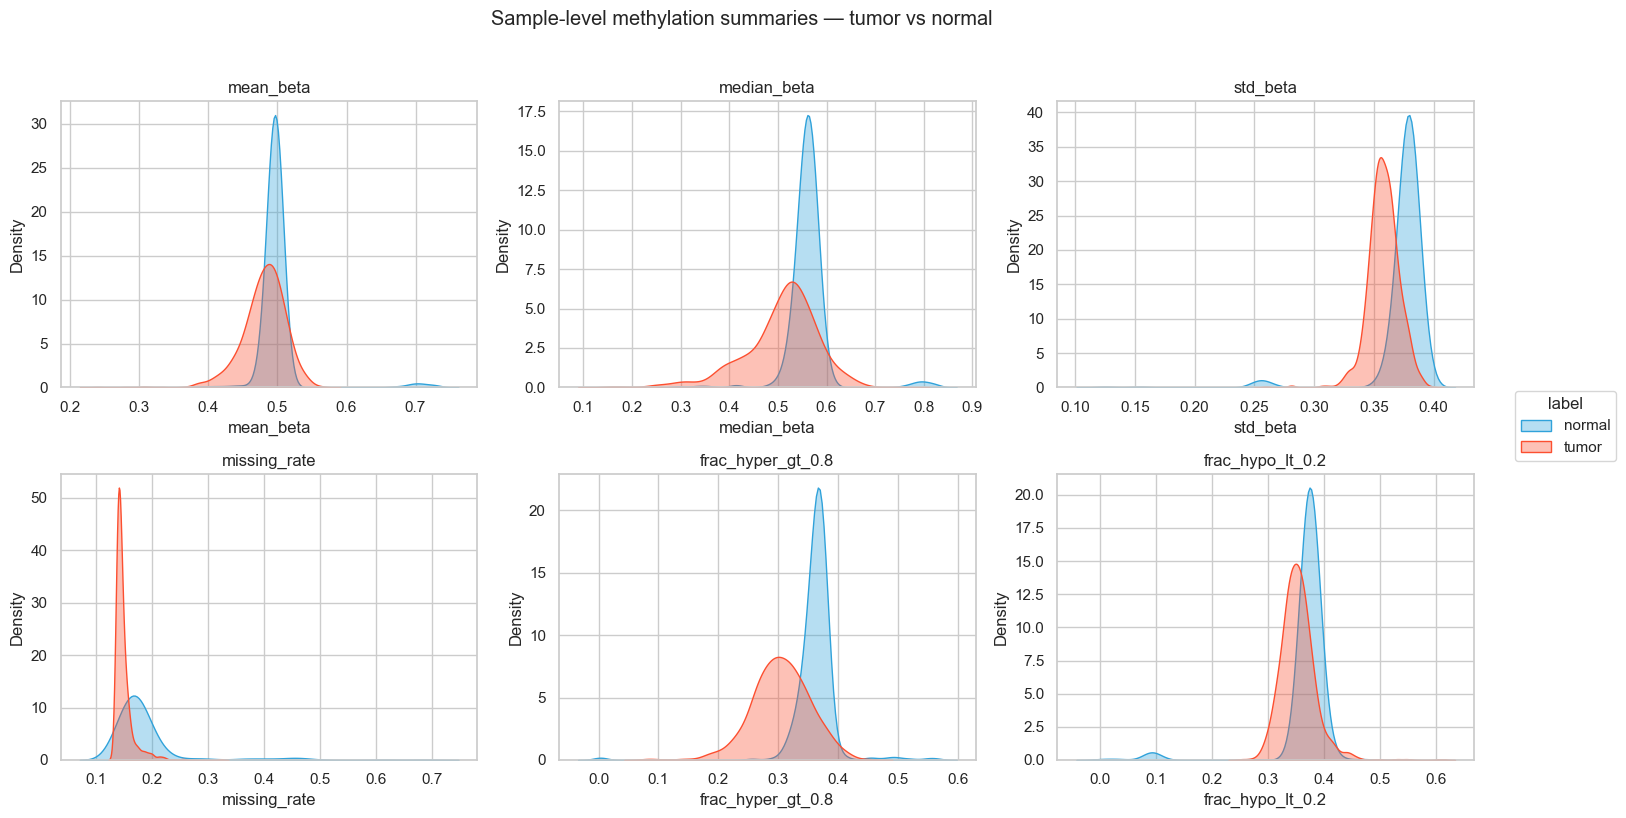

Welch t-tests (tumor vs normal) on sample summaries:
  mean_beta               Δmean(tumor-normal)=-0.0204  t=-9.62  p=1.24e-20
  median_beta             Δmean(tumor-normal)=-0.0553  t=-15.26  p=8.29e-48
  std_beta                Δmean(tumor-normal)=-0.0162  t=-11.21  p=6.74e-26
  missing_rate            Δmean(tumor-normal)=-0.0385  t=-10.47  p=9.09e-23
  frac_hyper_gt_0.8       Δmean(tumor-normal)=-0.0583  t=-22.49  p=3.10e-89
  frac_hypo_lt_0.2        Δmean(tumor-normal)=-0.0132  t=-4.54  p=7.16e-06


In [4]:
# Continuous sample-summary distributions by class
metrics = ["mean_beta", "median_beta", "std_beta", "missing_rate", "frac_hyper_gt_0.8", "frac_hypo_lt_0.2"]
f, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), metrics):
    for lab, color in [("normal", "#30a2da"), ("tumor", "#fc4f30")]:
        s = summary.loc[summary["label"] == lab, col]
        sns.kdeplot(s, ax=ax, fill=True, alpha=0.35, label=lab, color=color)
    ax.set_title(col)
handles, labels = axes[0, 0].get_legend_handles_labels()
f.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True, title="label")
f.subplots_adjust(right=0.82)
f.suptitle("Sample-level methylation summaries — tumor vs normal", y=1.02)
plt.tight_layout()
plt.show()

print("Welch t-tests (tumor vs normal) on sample summaries:")
for col in metrics:
    a = summary.loc[summary["label"] == "tumor", col]
    b = summary.loc[summary["label"] == "normal", col]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    print(f"  {col:22s}  Δmean(tumor-normal)={a.mean()-b.mean():+.4f}  t={t:+.2f}  p={p:.2e}")


**How to Interpret:** <br>
Overlapping KDEs mean genome-wide averages are similar; separated peaks suggest a systemic shift. Welch tests ignore unequal variance and unequal n — appropriate here because tumor n ≫ normal n.

**Interpretation:** <br>
Watch especially `std_beta` and the hyper/hypo fractions. Tumors often show **disrupted methylation landscapes** (more variance, altered tails) even when the mean β barely moves. If mean_beta’s p-value is weak while `frac_hyper_gt_0.8` or `std_beta` separates, that is already a scientifically coherent story.


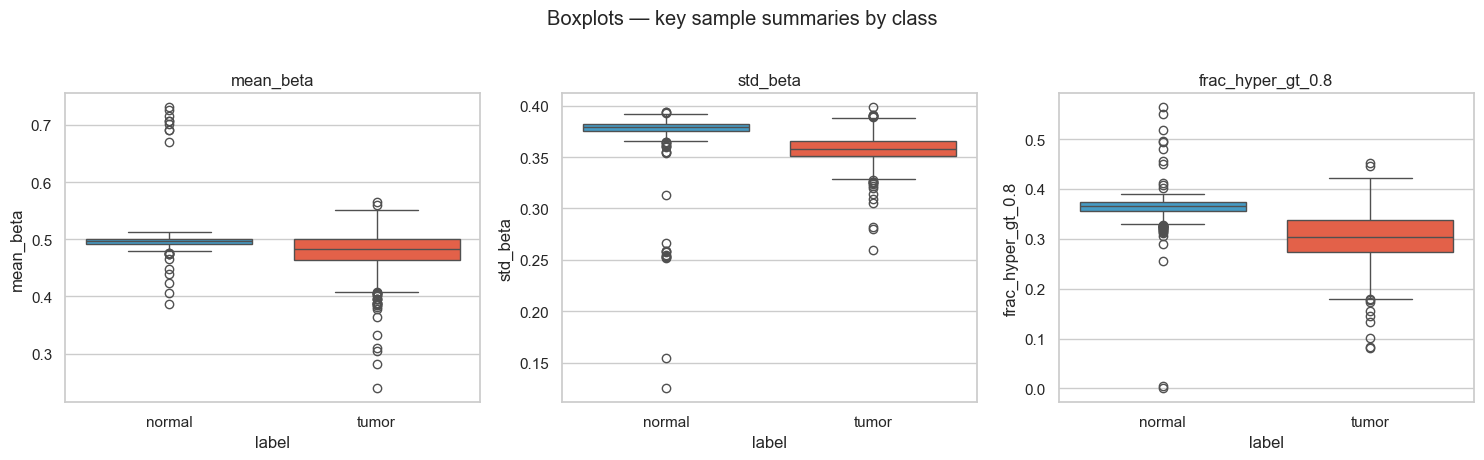

label
tumor     844
normal    371
Tumor fraction: 69.5%


In [5]:
f, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["mean_beta", "std_beta", "frac_hyper_gt_0.8"]):
    sns.boxplot(data=summary, x="label", y=col, ax=ax, palette=["#30a2da", "#fc4f30"])
    ax.set_title(col)
plt.suptitle("Boxplots — key sample summaries by class", y=1.02)
plt.tight_layout()
plt.show()

# Class counts
print(summary["label"].value_counts().to_string())
print("Tumor fraction: {:.1%}".format((summary["label"] == "tumor").mean()))


**Interpretation:** <br>
Boxplots make medians and outliers concrete. Outlier samples with extreme missingness or extreme mean β deserve a mental flag — they may be technical failures rather than biology. I keep them for transparency unless missing_rate is pathological across the board.


# **5. Missingness and Extreme Methylation:** <a id="Missing"></a>

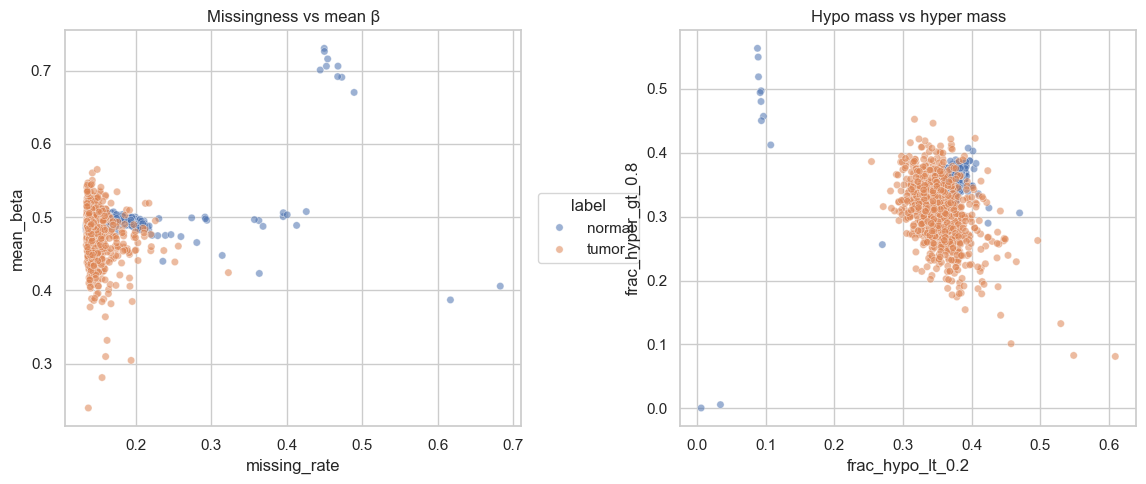

Missing rate by class:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
normal,371.0,0.186185,0.070002,0.134483,0.156731,0.169640,0.185939,0.682659
tumor,844.0,0.147659,0.016651,0.134752,0.138594,0.142357,0.149847,0.322790


In [6]:
f, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(
    data=summary, x="missing_rate", y="mean_beta", hue="label",
    alpha=0.55, s=28, ax=axes[0],
)
axes[0].set_title("Missingness vs mean β")
sns.move_legend(axes[0], "center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

sns.scatterplot(
    data=summary, x="frac_hypo_lt_0.2", y="frac_hyper_gt_0.8", hue="label",
    alpha=0.55, s=28, ax=axes[1], legend=False,
)
axes[1].set_title("Hypo mass vs hyper mass")
plt.tight_layout()
f.subplots_adjust(right=0.88, wspace=0.35)
plt.show()

print("Missing rate by class:")
display(summary.groupby("label")["missing_rate"].describe())


**Interpretation:** <br>
If missingness correlates with mean β *within* a class, technical dropout may bias summaries — worth knowing before over-interpreting small mean shifts. The hypo-vs-hyper scatter asks whether tumors trade one tail for the other (global hypomethylation with focal hypermethylation is a classic cancer motif). Overlap is expected; look for *shifts of the cloud*, not perfect separation.


# **6. Probe Subsample Matrix:** <a id="Matrix"></a>

In [7]:
# Build a manageable probe × sample matrix for multivariate EDA
RNG = np.random.default_rng(42)
N_NORMAL = min(80, len(normal_files))
N_TUMOR = min(120, len(tumor_files))
N_PROBES = 2000

picked_normal = list(RNG.choice(normal_files, size=N_NORMAL, replace=False))
picked_tumor = list(RNG.choice(tumor_files, size=N_TUMOR, replace=False))
probe_idx = np.sort(RNG.choice(EXPECTED_N_PROBES, size=N_PROBES, replace=False))

print(f"Subsample: {N_NORMAL} normal + {N_TUMOR} tumor samples × {N_PROBES} probes")


def load_probe_slice(path: Path, idx: np.ndarray) -> np.ndarray:
    v = np.loadtxt(path)
    assert len(v) == EXPECTED_N_PROBES
    sl = v[idx].astype(float)
    sl[sl == MISSING_SENTINEL] = np.nan
    return sl


rows = []
row_labels = []
row_ids = []
for lab, files in [("normal", picked_normal), ("tumor", picked_tumor)]:
    for p in files:
        rows.append(load_probe_slice(p, probe_idx))
        row_labels.append(lab)
        row_ids.append(p.stem)

X_raw = np.vstack(rows)
y = np.array(row_labels)
print("Matrix shape (samples × probes):", X_raw.shape)
print("Overall NaN rate in subsample:", np.isnan(X_raw).mean().round(4))

# Drop probes that are entirely missing in this subsample, then median-impute
keep = ~np.all(np.isnan(X_raw), axis=0)
print(f"Dropping {int((~keep).sum())} all-missing probes in subsample; keeping {int(keep.sum())}")
X_raw = X_raw[:, keep]
probe_idx = probe_idx[keep]
N_PROBES = int(keep.sum())
assert N_PROBES > 100, "too few usable probes in subsample"

col_med = np.nanmedian(X_raw, axis=0)
assert np.isfinite(col_med).all(), "column medians still non-finite after drop"
inds = np.where(np.isnan(X_raw))
X = X_raw.copy()
X[inds] = np.take(col_med, inds[1])
assert np.isfinite(X).all()
print("After median impute: shape", X.shape, "finite=", np.isfinite(X).all())


Subsample: 80 normal + 120 tumor samples × 2000 probes


Matrix shape (samples × probes): (200, 2000)
Overall NaN rate in subsample: 0.1677
Dropping 278 all-missing probes in subsample; keeping 1722
After median impute: shape (200, 1722) finite= True


**Code Explanation:** <br>
I deliberately **do not** load 453k × 1,215 into memory. Instead I sample 200 samples and 2,000 probes with a fixed RNG seed so the notebook is reproducible. Missing `-1`s become NaN, then column-median imputed *for visualization / PCA only* — this is an EDA convenience, not a claim that medians are biologically true.

**How to Interpret:** <br>
Results from this subsample are **hypothesis-generating**. A probe that looks huge here should be replicated on a fuller probe set before anyone writes it up as a biomarker.


# **7. PCA and Class Separation:** <a id="PCA"></a>

Variance explained: [0.154 0.081 0.058 0.041 0.033]
Cumulative: [0.154 0.234 0.293 0.333 0.366]


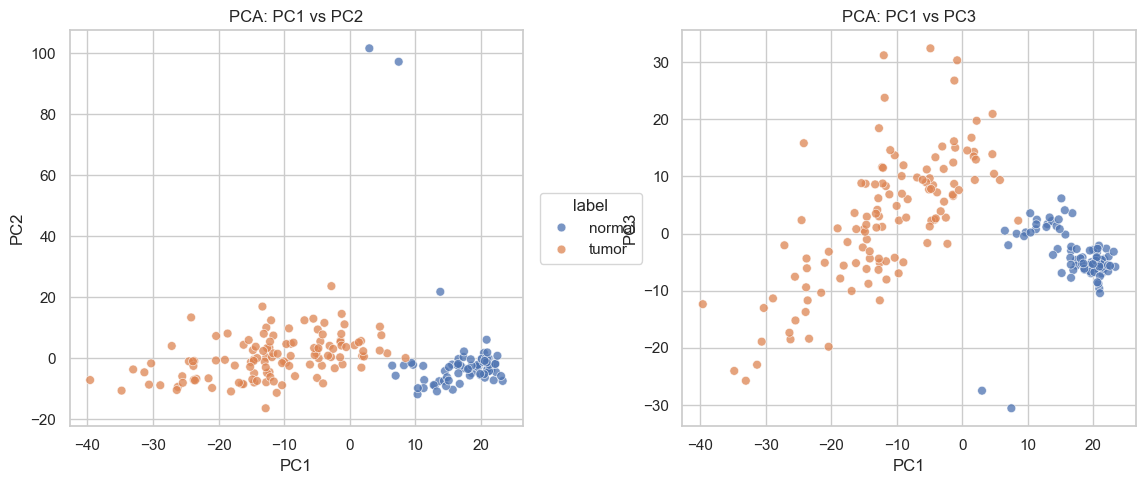

PC1 tumor vs normal: Δ=-28.934 t=-28.42 p=1.52e-68


In [8]:
# PCA on standardized probe subsample
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
pca = PCA(n_components=5, random_state=0)
Z = pca.fit_transform(Xs)

pca_df = pd.DataFrame(Z, columns=[f"PC{i+1}" for i in range(Z.shape[1])])
pca_df["label"] = y
pca_df["sample_id"] = row_ids

print("Variance explained:", np.round(pca.explained_variance_ratio_, 3))
print("Cumulative:", np.round(np.cumsum(pca.explained_variance_ratio_), 3))

f, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="label", alpha=0.75, s=40, ax=axes[0])
axes[0].set_title("PCA: PC1 vs PC2")
sns.move_legend(axes[0], "center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

sns.scatterplot(data=pca_df, x="PC1", y="PC3", hue="label", alpha=0.75, s=40, ax=axes[1], legend=False)
axes[1].set_title("PCA: PC1 vs PC3")
plt.tight_layout()
f.subplots_adjust(right=0.88, wspace=0.35)
plt.show()

# Simple linear separability check on PC1
t, p = stats.ttest_ind(
    pca_df.loc[pca_df["label"] == "tumor", "PC1"],
    pca_df.loc[pca_df["label"] == "normal", "PC1"],
    equal_var=False,
)
print(f"PC1 tumor vs normal: Δ={pca_df.loc[pca_df.label=='tumor','PC1'].mean()-pca_df.loc[pca_df.label=='normal','PC1'].mean():+.3f} t={t:+.2f} p={p:.2e}")


**Interpretation:** <br>
If PC1 already shifts tumor away from normal, the random probe slice still carries class signal — encouraging, because we did not cherry-pick probes. If clouds overlap heavily, either the signal is locus-specific (need differential selection) or technical batch structure dominates the leading PCs. Always read explained-variance ratios: a beautiful scatter on 3% variance is a weak story.


5-fold ROC-AUC (PCs + sample summaries): mean=0.999 ± 0.002
Fold scores: [1.    0.995 1.    1.    1.   ]

RF importances:
PC1                  0.406187
std_beta             0.199801
frac_hyper_gt_0.8    0.149030
PC3                  0.091079
missing_rate         0.075808
mean_beta            0.052535
PC2                  0.025560


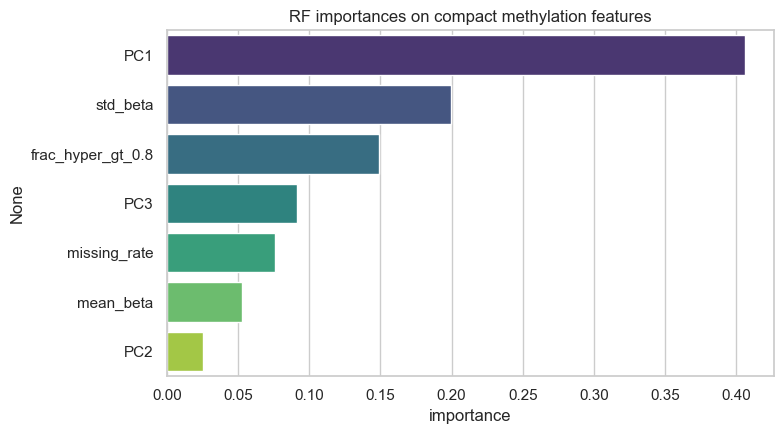

In [9]:
# Light RF on subsample — associational, CV accuracy as a ceiling check
clf = RandomForestClassifier(
    n_estimators=200, random_state=0, n_jobs=-1, class_weight="balanced"
)
# Use first 3 PCs + a few sample summaries merged for a compact feature set
sum_sub = summary.set_index("sample_id").loc[row_ids]
feat = pca_df[["PC1", "PC2", "PC3"]].copy()
feat["mean_beta"] = sum_sub["mean_beta"].to_numpy()
feat["std_beta"] = sum_sub["std_beta"].to_numpy()
feat["missing_rate"] = sum_sub["missing_rate"].to_numpy()
feat["frac_hyper_gt_0.8"] = sum_sub["frac_hyper_gt_0.8"].to_numpy()

scores = cross_val_score(clf, feat, y, cv=5, scoring="roc_auc")
print("5-fold ROC-AUC (PCs + sample summaries): mean={:.3f} ± {:.3f}".format(scores.mean(), scores.std()))
print("Fold scores:", np.round(scores, 3))

clf.fit(feat, y)
imp = pd.Series(clf.feature_importances_, index=feat.columns).sort_values(ascending=False)
print("\nRF importances:")
print(imp.to_string())

f, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=imp.values, y=imp.index, hue=imp.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("importance")
ax.set_title("RF importances on compact methylation features")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Cross-validated AUC on this *tiny engineered feature set* is a sanity check, not a biomarker paper. High AUC means tumor/normal differ in the summary+PC space; low AUC means our compression discarded the signal (try more probes / supervised probe selection next).


# **8. Differential Probes (Exploratory):** <a id="Diff"></a>

Probes tested: 1715
p < 0.01 count: 1154
p < 1e-5 count: 829


,probe_index,delta_tumor_minus_normal,t,p,neglog10p
1386,366351,0.175500,25.331946,7.914233e-62,61.101591
367,93589,-0.324704,-23.782542,1.170231e-59,58.931728
228,57926,-0.262854,-22.361383,7.224757e-56,55.141177
1041,276111,-0.420036,-24.661687,8.938694e-54,53.048726
859,227397,-0.315431,-23.965692,8.723635e-52,51.059303
1591,418867,-0.232323,-21.201532,2.172263e-50,49.663088
1643,431983,0.356853,21.037636,3.576476e-49,48.446545
1686,442951,-0.250232,-19.996176,3.817589e-49,48.418211
863,227785,0.329300,21.751052,6.706433e-48,47.173508
1078,285524,-0.234183,-19.451202,1.485577e-47,46.828105


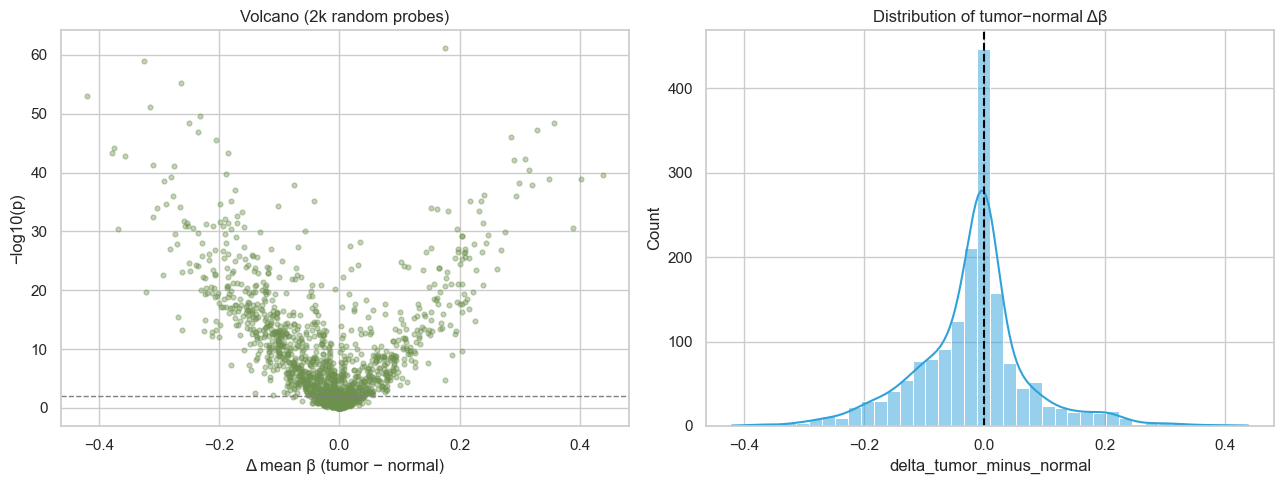

In [10]:
# Welch t-test per probe in the subsample (exploratory; not genome-wide significant by itself)
tumor_mask = y == "tumor"
normal_mask = y == "normal"
# use X_raw with NaNs — ttest_ind handles via nan_policy
t_stats = np.empty(N_PROBES)
p_vals = np.empty(N_PROBES)
delta = np.empty(N_PROBES)
for j in range(N_PROBES):
    a = X_raw[tumor_mask, j]
    b = X_raw[normal_mask, j]
    # drop nans per probe
    a = a[~np.isnan(a)]
    b = b[~np.isnan(b)]
    if len(a) < 10 or len(b) < 10:
        t_stats[j] = np.nan
        p_vals[j] = np.nan
        delta[j] = np.nan
        continue
    t, p = stats.ttest_ind(a, b, equal_var=False)
    t_stats[j] = t
    p_vals[j] = p
    delta[j] = a.mean() - b.mean()

diff = pd.DataFrame({
    "probe_index": probe_idx,
    "delta_tumor_minus_normal": delta,
    "t": t_stats,
    "p": p_vals,
}).dropna()
diff["neglog10p"] = -np.log10(diff["p"].clip(lower=1e-300))
print("Probes tested:", len(diff))
print("p < 0.01 count:", int((diff["p"] < 0.01).sum()))
print("p < 1e-5 count:", int((diff["p"] < 1e-5).sum()))
display(diff.reindex(diff["neglog10p"].abs().sort_values(ascending=False).index).head(10))

f, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(diff["delta_tumor_minus_normal"], diff["neglog10p"], s=12, alpha=0.4, c="#6d904f")
axes[0].axhline(-np.log10(0.01), ls="--", color="gray", lw=1)
axes[0].set_xlabel("Δ mean β (tumor − normal)")
axes[0].set_ylabel("−log10(p)")
axes[0].set_title("Volcano (2k random probes)")

sns.histplot(diff["delta_tumor_minus_normal"], bins=40, kde=True, ax=axes[1], color="#30a2da")
axes[1].axvline(0, color="black", ls="--")
axes[1].set_title("Distribution of tumor−normal Δβ")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
This volcano uses **2,000 randomly chosen probes**, not the full 450K array. p-values are **not** Bonferroni-corrected to the whole epigenome — treat stars as “interesting in this draw,” not as GWAS-grade hits. The Δβ histogram should be roughly centered if global means match; fat tails suggest locus-specific shifts in both directions.

**Interpretation:** <br>
A classic cancer pattern is **many small opposing effects** (global hypo + promoter hyper) rather than one huge mean shift. If the volcano shows hits on both sides of Δ=0, that matches the textbook motif even in a random slice.


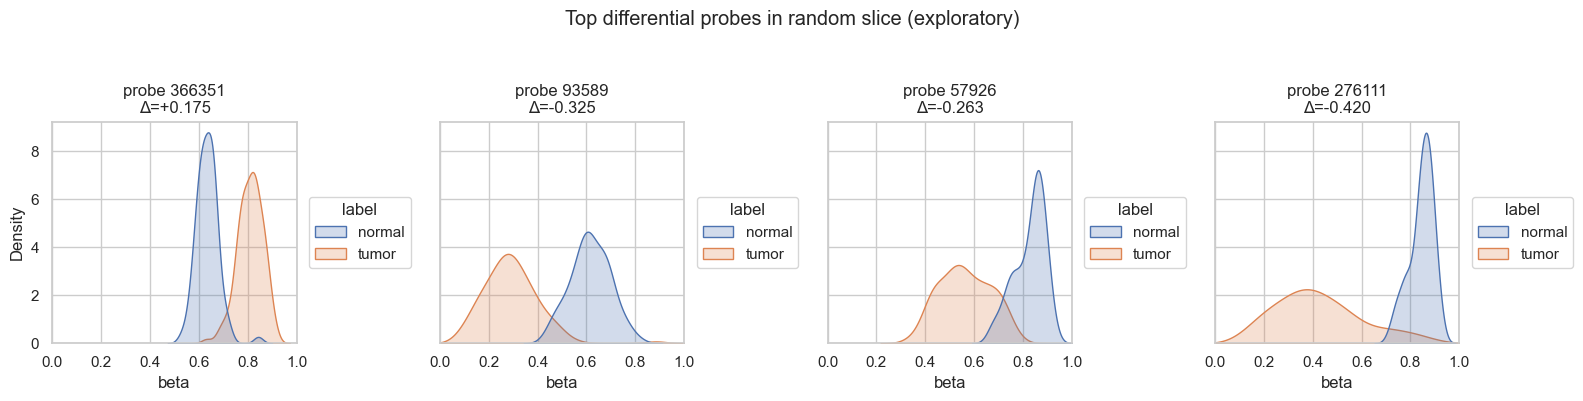

In [11]:
# Show methylation distributions for top 4 differential probes in the subsample
top4 = diff.reindex(diff["neglog10p"].abs().sort_values(ascending=False).index).head(4)
f, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
for ax, (_, row) in zip(axes, top4.iterrows()):
    j = int(np.where(probe_idx == int(row["probe_index"]))[0][0])
    plot_df = pd.DataFrame({"beta": X_raw[:, j], "label": y}).dropna()
    sns.kdeplot(data=plot_df, x="beta", hue="label", fill=True, ax=ax, common_norm=False)
    ax.set_title(f"probe {int(row['probe_index'])}\nΔ={row['delta_tumor_minus_normal']:+.3f}")
    ax.set_xlim(0, 1)
    if ax.get_legend() is not None:
        sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), frameon=True, title="label")
plt.suptitle("Top differential probes in random slice (exploratory)", y=1.05)
plt.tight_layout()
plt.show()


**Interpretation:** <br>
Per-probe KDEs that separate cleanly are candidates for follow-up (annotation to genes/CpG islands, replication on held-out samples, full-array screen). Per-probe KDEs that barely budge despite a “significant” p-value remind us that with n≈200, tiny Δβ can still get small p — always pair significance with **effect size**.


# **9. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the archive is:** <br>
1,215 breast methylation vectors (371 normal / 844 tumor), each **453,001** β-values with `-1` missing. Fixed probe order makes sample-wise aggregation and probe-wise slicing valid.

**What the sample-level layer showed:** <br>
Genome-wide means may shift only modestly; variance, missingness, and hyper/hypo mass are often the more honest “landscape” descriptors. Cache the summary table — it is the affordable map of the whole cohort.

**What the probe subsample showed:** <br>
Even a random 2,000-probe slice can carry class signal in PCA / compact RF space, and volcano plots typically reveal **bidirectional** locus effects. That is consistent with cancer epigenomics, but this notebook’s hits are **not** genome-wide discoveries.

**What to do next (natural follow-up cells):** <br>
1. Annotate top probes to genes / CGI context (requires a 450K manifest join).  
2. Increase probe subsample or run chunked full-array Welch screens with FDR control.  
3. Batch / plate covariates if metadata become available — leading PCs sometimes are technical.  
4. Supervised feature selection (e.g. mutual information) before PCA, with held-out samples.  
5. Compare tumor-only heterogeneity (subclusters) — not all tumors share one methylation story.

Use these plots as a guided tour of a large epigenetic archive — associations and leads, not a diagnostic model.
***
